# Prospective Memory Analysis (From Pre-Sampled Trajectories)

This notebook reproduces the prospective-memory geometric analysis pipeline, but uses already-saved teacher trajectories from:

`results_link_sampler/index_cued_first_diffusion_0.3_swap_recovery_6/ablated_teacher_trajectories`

It avoids model sampling and instead loads `ablated_teacher_trajectories_sweep_step_*.pt` files, extracts `postprep_state` at each `prep_idx`, and runs the same cue/color PCA and plane analyses.

In [15]:
import os
import sys
import json
import colorsys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

SEED = 42
np.random.seed(SEED)

REPO_ROOT = Path('/scratch3/shaiq_home/repos/behaviour_ddpm')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

TRAJ_DIR = REPO_ROOT / 'results_link_sampler' / 'index_cued_first_diffusion_0.3_swap_recovery_6' / 'ablated_teacher_trajectories'
RUN_NAME = TRAJ_DIR.parent.name
RESULTS_DIR = REPO_ROOT / 'ddpm' / 'analysis' / 'new_analysis' / 'results' / f'{RUN_NAME}_sampled_trajectories'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

PREP_INDICES = [0, 1, 2, 3]
PREP_IDX = 2
N_BINS = 12

print(f'Working directory: {os.getcwd()}')
print(f'Trajectory directory: {TRAJ_DIR}')
print(f'Results directory: {RESULTS_DIR}')

Working directory: /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis
Trajectory directory: /scratch3/shaiq_home/repos/behaviour_ddpm/results_link_sampler/index_cued_first_diffusion_0.3_swap_recovery_6/ablated_teacher_trajectories
Results directory: /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis/results/index_cued_first_diffusion_0.3_swap_recovery_6_sampled_trajectories


In [2]:
def list_sweep_files(traj_dir: Path):
    files = sorted(traj_dir.glob('ablated_teacher_trajectories_sweep_step_*.pt'))
    if not files:
        raise FileNotFoundError(f'No sweep files found in {traj_dir}')
    return files


def load_states_and_metadata_from_sweeps(traj_dir: Path, prep_indices=(0, 1, 2, 3), reduce_samples='mean'):
    sweep_files = list_sweep_files(traj_dir)

    states_by_prep = {idx: [] for idx in prep_indices}
    metadata_rows = []

    for fi, path in enumerate(sweep_files):
        data = torch.load(path, map_location='cpu', weights_only=False)

        trials = data.get('sweep_batch_trials', None)
        prep_dicts = data.get('ablated_teacher_prep_dicts', None)

        if trials is None or prep_dicts is None:
            continue

        for prep_idx in prep_indices:
            postprep = prep_dicts[prep_idx]['postprep_state']  # [batch, samples, dim]
            if reduce_samples == 'mean':
                postprep_reduced = postprep.mean(dim=1)
            elif reduce_samples == 'first':
                postprep_reduced = postprep[:, 0, :]
            else:
                raise ValueError(f'Unknown reduce_samples={reduce_samples}')

            states_by_prep[prep_idx].append(postprep_reduced.numpy())

        for tr in trials:
            metadata_rows.append([int(tr['cue']), float(tr['color1_angle']), float(tr['color2_angle'])])

        if (fi + 1) % 25 == 0:
            print(f'Loaded {fi + 1}/{len(sweep_files)} files...')

    if len(metadata_rows) == 0:
        raise RuntimeError('No valid sweep rows loaded. Check trajectory files.')

    metadata = np.asarray(metadata_rows, dtype=np.float32)
    for prep_idx in prep_indices:
        states_by_prep[prep_idx] = np.concatenate(states_by_prep[prep_idx], axis=0)

    return states_by_prep, metadata, sweep_files


def bin_angle(angle, bin_size):
    return int(angle // bin_size) % int(360 // bin_size)


def bin_and_average_by_cued_color(states, metadata, n_bins=12):
    bin_size = 360.0 / n_bins

    binned_data = {
        1: {b: [] for b in range(n_bins)},
        2: {b: [] for b in range(n_bins)},
    }

    for i, (cue, c1, c2) in enumerate(metadata):
        cue = int(cue)
        cued_angle = c1 if cue == 1 else c2
        b = bin_angle(cued_angle, bin_size)
        binned_data[cue][b].append(states[i])

    averaged = {
        1: np.zeros((n_bins, states.shape[1]), dtype=np.float32),
        2: np.zeros((n_bins, states.shape[1]), dtype=np.float32),
    }

    for cue in [1, 2]:
        for b in range(n_bins):
            if len(binned_data[cue][b]) > 0:
                averaged[cue][b] = np.mean(binned_data[cue][b], axis=0)
            else:
                averaged[cue][b] = np.nan

    return averaged, binned_data


def bin_by_target_and_distractor(states, metadata, n_bins=12):
    bin_size = 360.0 / n_bins

    binned = {1: {}, 2: {}}

    for i, (cue, c1, c2) in enumerate(metadata):
        cue = int(cue)
        if cue == 1:
            target_angle = c1
            distractor_angle = c2
        else:
            target_angle = c2
            distractor_angle = c1

        tb = bin_angle(target_angle, bin_size)
        db = bin_angle(distractor_angle, bin_size)
        key = (tb, db)

        if key not in binned[cue]:
            binned[cue][key] = []
        binned[cue][key].append(states[i])

    averaged = {1: {}, 2: {}}
    counts = {1: {}, 2: {}}
    for cue in [1, 2]:
        for key, vals in binned[cue].items():
            averaged[cue][key] = np.mean(vals, axis=0)
            counts[cue][key] = len(vals)

    return averaged, counts


def fit_plane_to_data(data):
    center = np.mean(data, axis=0)
    centered = data - center
    pca = PCA(n_components=3)
    pca.fit(centered)

    normal = pca.components_[2]
    normal = normal / np.linalg.norm(normal)
    variance = pca.explained_variance_ratio_
    planarity = variance[:2].sum()
    return normal, center, planarity, variance


def angle_between_planes_degrees(normal1, normal2):
    cos_angle = np.abs(np.dot(normal1, normal2))
    cos_angle = min(1.0, max(0.0, cos_angle))
    return np.degrees(np.arccos(cos_angle))

In [5]:
states_by_prep, metadata, sweep_files = load_states_and_metadata_from_sweeps(
    TRAJ_DIR,
    prep_indices=tuple(PREP_INDICES),
    reduce_samples='mean',
)

print(f'Loaded {len(sweep_files)} sweep files')
print(f'Total trials: {metadata.shape[0]}')
for prep_idx in PREP_INDICES:
    print(f'prep_idx={prep_idx} states shape: {states_by_prep[prep_idx].shape}')

neural_states = states_by_prep[PREP_IDX]
print(f'\nUsing PREP_IDX={PREP_IDX} for primary analysis')
print(f'Primary neural state shape: {neural_states.shape}')

Loaded 25/288 files...
Loaded 50/288 files...
Loaded 75/288 files...
Loaded 100/288 files...
Loaded 125/288 files...
Loaded 150/288 files...
Loaded 175/288 files...
Loaded 200/288 files...
Loaded 225/288 files...
Loaded 250/288 files...
Loaded 275/288 files...
Loaded 288 sweep files
Total trials: 9216
prep_idx=0 states shape: (9216, 16)
prep_idx=1 states shape: (9216, 16)
prep_idx=2 states shape: (9216, 16)
prep_idx=3 states shape: (9216, 16)

Using PREP_IDX=2 for primary analysis
Primary neural state shape: (9216, 16)


In [6]:
cue1_mask = metadata[:, 0] == 1
cue2_mask = metadata[:, 0] == 2

cue1_states = neural_states[cue1_mask]
cue2_states = neural_states[cue2_mask]

cue1_mean = cue1_states.mean(axis=0)
cue2_mean = cue2_states.mean(axis=0)

print(f'Cue 1 trials: {len(cue1_states)}')
print(f'Cue 2 trials: {len(cue2_states)}')
print('Difference between cue means:')
print(f'  Max abs diff: {np.abs(cue1_mean - cue2_mean).max():.6f}')
print(f'  Mean abs diff: {np.abs(cue1_mean - cue2_mean).mean():.6f}')
print(f'  L2 distance: {np.linalg.norm(cue1_mean - cue2_mean):.6f}')

Cue 1 trials: 4608
Cue 2 trials: 4608
Difference between cue means:
  Max abs diff: 19.084045
  Mean abs diff: 8.317717
  L2 distance: 38.904419


In [7]:
averaged_states, binned_trials = bin_and_average_by_cued_color(neural_states, metadata, n_bins=N_BINS)

print(f'Binned into {N_BINS} bins (30 deg) by cued color')
for cue in [1, 2]:
    counts = [len(binned_trials[cue][b]) for b in range(N_BINS)]
    print(f'  Cue {cue} counts: {counts}')

all_binned_states = np.vstack([averaged_states[1], averaged_states[2]])
valid_mask = ~np.isnan(all_binned_states).any(axis=1)
all_binned_states_clean = all_binned_states[valid_mask]

pca = PCA(n_components=min(3, all_binned_states_clean.shape[0] - 1))
pca_coords = pca.fit_transform(all_binned_states_clean)

cue1_pca = pca_coords[:N_BINS]
cue2_pca = pca_coords[N_BINS:N_BINS * 2]

cue1_center = cue1_pca.mean(axis=0)
cue2_center = cue2_pca.mean(axis=0)
separation = np.linalg.norm(cue1_center - cue2_center)

print('PCA explained variance ratio:', pca.explained_variance_ratio_)
print('Cue separation in PCA space:', separation)

Binned into 12 bins (30 deg) by cued color
  Cue 1 counts: [384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384]
  Cue 2 counts: [384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384]
PCA explained variance ratio: [0.54176307 0.3069206  0.07014065]
Cue separation in PCA space: 34.767216


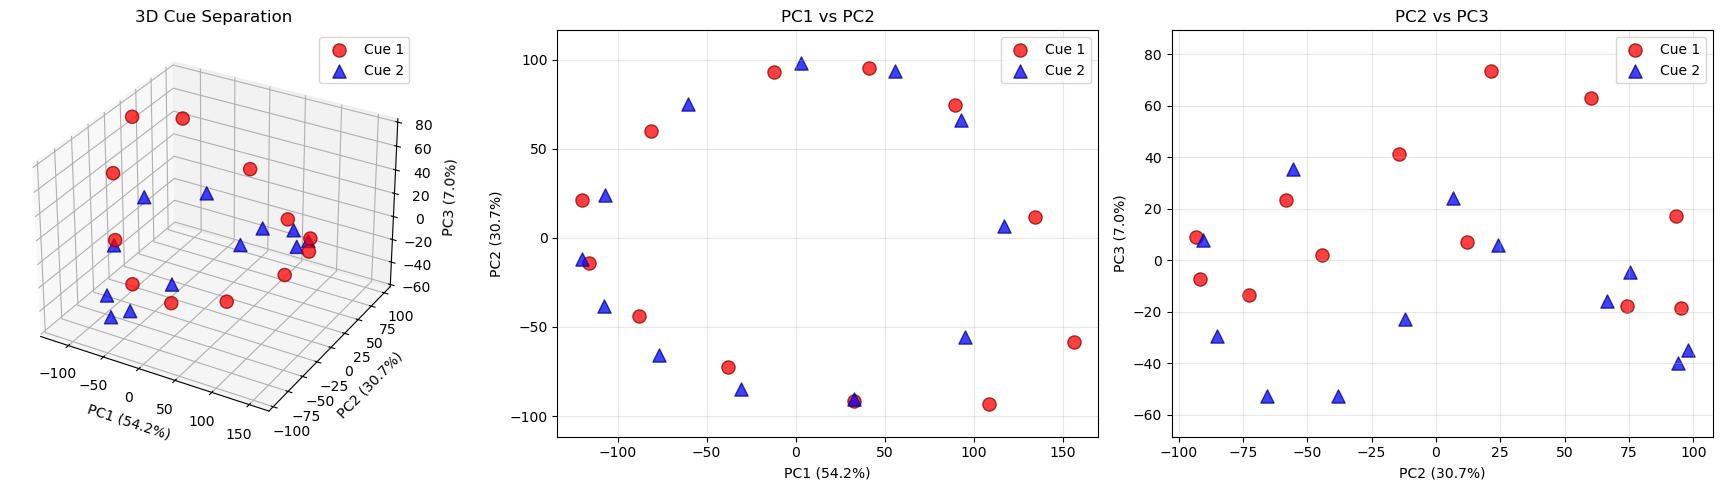

In [8]:
fig = plt.figure(figsize=(18, 5))

ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(cue1_pca[:, 0], cue1_pca[:, 1], cue1_pca[:, 2], c='red', marker='o', s=90, alpha=0.75, edgecolors='darkred', label='Cue 1')
ax1.scatter(cue2_pca[:, 0], cue2_pca[:, 1], cue2_pca[:, 2], c='blue', marker='^', s=90, alpha=0.75, edgecolors='darkblue', label='Cue 2')
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax1.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.1%})')
ax1.set_title('3D Cue Separation')
ax1.legend()

ax2 = fig.add_subplot(132)
ax2.scatter(cue1_pca[:, 0], cue1_pca[:, 1], c='red', marker='o', s=90, alpha=0.75, edgecolors='darkred', label='Cue 1')
ax2.scatter(cue2_pca[:, 0], cue2_pca[:, 1], c='blue', marker='^', s=90, alpha=0.75, edgecolors='darkblue', label='Cue 2')
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax2.set_title('PC1 vs PC2')
ax2.grid(True, alpha=0.3)
ax2.axis('equal')
ax2.legend()

ax3 = fig.add_subplot(133)
ax3.scatter(cue1_pca[:, 1], cue1_pca[:, 2], c='red', marker='o', s=90, alpha=0.75, edgecolors='darkred', label='Cue 1')
ax3.scatter(cue2_pca[:, 1], cue2_pca[:, 2], c='blue', marker='^', s=90, alpha=0.75, edgecolors='darkblue', label='Cue 2')
ax3.set_xlabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax3.set_ylabel(f'PC3 ({pca.explained_variance_ratio_[2]:.1%})')
ax3.set_title('PC2 vs PC3')
ax3.grid(True, alpha=0.3)
ax3.axis('equal')
ax3.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'prospective_memory_pca_3d_sampled.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
averaged_2d, bin_counts_2d = bin_by_target_and_distractor(neural_states, metadata, n_bins=N_BINS)

all_2d_states = []
all_2d_meta = []
for cue in [1, 2]:
    for (tb, db), state in averaged_2d[cue].items():
        all_2d_states.append(state)
        all_2d_meta.append((cue, tb, db))

all_2d_states = np.asarray(all_2d_states)
all_2d_meta = np.asarray(all_2d_meta)

pca_2d = PCA(n_components=3)
pca_coords_2d = pca_2d.fit_transform(all_2d_states)

cue1_mask_2d = all_2d_meta[:, 0] == 1
cue2_mask_2d = all_2d_meta[:, 0] == 2

cue1_pca_2d = pca_coords_2d[cue1_mask_2d]
cue2_pca_2d = pca_coords_2d[cue2_mask_2d]
cue1_meta_2d = all_2d_meta[cue1_mask_2d]
cue2_meta_2d = all_2d_meta[cue2_mask_2d]

print(f'Cue 1 non-empty 2D bins: {len(cue1_pca_2d)}')
print(f'Cue 2 non-empty 2D bins: {len(cue2_pca_2d)}')
print('2D-binned PCA explained variance ratio:', pca_2d.explained_variance_ratio_)

Cue 1 non-empty 2D bins: 144
Cue 2 non-empty 2D bins: 144
2D-binned PCA explained variance ratio: [0.47126597 0.25299594 0.09900485]


In [10]:
target_only = {}
distractor_only = {}

for tb in range(N_BINS):
    vals = []
    for cue in [1, 2]:
        for (tbin, dbin), state in averaged_2d[cue].items():
            if tbin == tb:
                vals.append(state)
    if vals:
        target_only[tb] = np.mean(vals, axis=0)

for db in range(N_BINS):
    vals = []
    for cue in [1, 2]:
        for (tbin, dbin), state in averaged_2d[cue].items():
            if dbin == db:
                vals.append(state)
    if vals:
        distractor_only[db] = np.mean(vals, axis=0)

combined_states = []
combined_meta = []
for b, st in sorted(target_only.items()):
    combined_states.append(st)
    combined_meta.append((0, b))
for b, st in sorted(distractor_only.items()):
    combined_states.append(st)
    combined_meta.append((1, b))

combined_states = np.asarray(combined_states)
combined_meta = np.asarray(combined_meta)

pca_combined = PCA(n_components=3)
combined_pca = pca_combined.fit_transform(combined_states)

target_pca = combined_pca[combined_meta[:, 0] == 0]
distractor_pca = combined_pca[combined_meta[:, 0] == 1]

target_normal, target_center, target_planarity, _ = fit_plane_to_data(target_pca)
distractor_normal, distractor_center, distractor_planarity, _ = fit_plane_to_data(distractor_pca)
plane_angle = angle_between_planes_degrees(target_normal, distractor_normal)
plane_sep = np.linalg.norm(target_center - distractor_center)

print('Combined target/distractor PCA explained variance:', pca_combined.explained_variance_ratio_)
print(f'Angle between target and distractor planes: {plane_angle:.2f} deg')
print(f'Center separation: {plane_sep:.4f}')
print(f'Target planarity: {target_planarity:.2%}')
print(f'Distractor planarity: {distractor_planarity:.2%}')

Combined target/distractor PCA explained variance: [0.5963908  0.342368   0.04634694]
Angle between target and distractor planes: 12.01 deg
Center separation: 0.0000
Target planarity: 94.76%
Distractor planarity: 96.75%


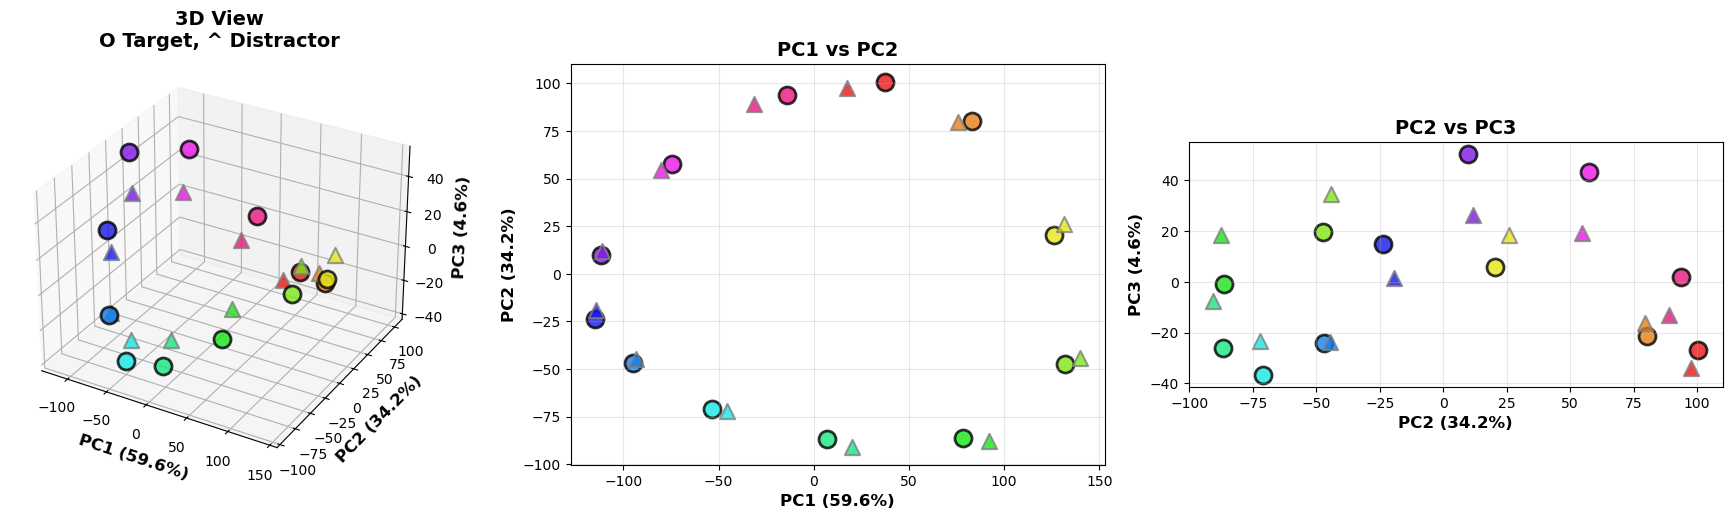

Saved: /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis/results/index_cued_first_diffusion_0.3_swap_recovery_6_sampled_trajectories/2d_binning_target_vs_distractor_combined.png


In [16]:
# Visualisation: target vs distractor encoding (combined), matching original layout
N_COLOR_BINS = 12

target_bins_combined = combined_meta[combined_meta[:, 0] == 0, 1].astype(int)
distractor_bins_combined = combined_meta[combined_meta[:, 0] == 1, 1].astype(int)

def angle_to_colour(bin_idx, n_bins=12):
    hue = bin_idx / n_bins
    return colorsys.hsv_to_rgb(hue, 0.9, 0.9)

fig = plt.figure(figsize=(18, 5))

ax = fig.add_subplot(131, projection='3d')
for i in range(len(target_pca)):
    colour = angle_to_colour(target_bins_combined[i], N_COLOR_BINS)
    ax.scatter(target_pca[i, 0], target_pca[i, 1], target_pca[i, 2], c=[colour], marker='o', s=150, alpha=0.8, edgecolors='k', linewidth=2)
for i in range(len(distractor_pca)):
    colour = angle_to_colour(distractor_bins_combined[i], N_COLOR_BINS)
    ax.scatter(distractor_pca[i, 0], distractor_pca[i, 1], distractor_pca[i, 2], c=[colour], marker='^', s=120, alpha=0.8, edgecolors='grey', linewidth=1.5)
ax.set_xlabel(f'PC1 ({pca_combined.explained_variance_ratio_[0]:.1%})', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca_combined.explained_variance_ratio_[1]:.1%})', fontsize=12, fontweight='bold')
ax.set_zlabel(f'PC3 ({pca_combined.explained_variance_ratio_[2]:.1%})', fontsize=12, fontweight='bold')
ax.set_title('3D View\nO Target, ^ Distractor', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

ax2 = fig.add_subplot(132)
for i in range(len(target_pca)):
    colour = angle_to_colour(target_bins_combined[i], N_COLOR_BINS)
    ax2.scatter(target_pca[i, 0], target_pca[i, 1], c=[colour], marker='o', s=150, alpha=0.8, edgecolors='k', linewidth=2)
for i in range(len(distractor_pca)):
    colour = angle_to_colour(distractor_bins_combined[i], N_COLOR_BINS)
    ax2.scatter(distractor_pca[i, 0], distractor_pca[i, 1], c=[colour], marker='^', s=120, alpha=0.8, edgecolors='grey', linewidth=1.5)
ax2.set_xlabel(f'PC1 ({pca_combined.explained_variance_ratio_[0]:.1%})', fontsize=12, fontweight='bold')
ax2.set_ylabel(f'PC2 ({pca_combined.explained_variance_ratio_[1]:.1%})', fontsize=12, fontweight='bold')
ax2.set_title('PC1 vs PC2', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal')

ax3 = fig.add_subplot(133)
for i in range(len(target_pca)):
    colour = angle_to_colour(target_bins_combined[i], N_COLOR_BINS)
    ax3.scatter(target_pca[i, 1], target_pca[i, 2], c=[colour], marker='o', s=150, alpha=0.8, edgecolors='k', linewidth=2)
for i in range(len(distractor_pca)):
    colour = angle_to_colour(distractor_bins_combined[i], N_COLOR_BINS)
    ax3.scatter(distractor_pca[i, 1], distractor_pca[i, 2], c=[colour], marker='^', s=120, alpha=0.8, edgecolors='grey', linewidth=1.5)
ax3.set_xlabel(f'PC2 ({pca_combined.explained_variance_ratio_[1]:.1%})', fontsize=12, fontweight='bold')
ax3.set_ylabel(f'PC3 ({pca_combined.explained_variance_ratio_[2]:.1%})', fontsize=12, fontweight='bold')
ax3.set_title('PC2 vs PC3', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.set_aspect('equal')

plt.tight_layout()
plt.savefig(RESULTS_DIR / '2d_binning_target_vs_distractor_combined.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved:', RESULTS_DIR / '2d_binning_target_vs_distractor_combined.png')

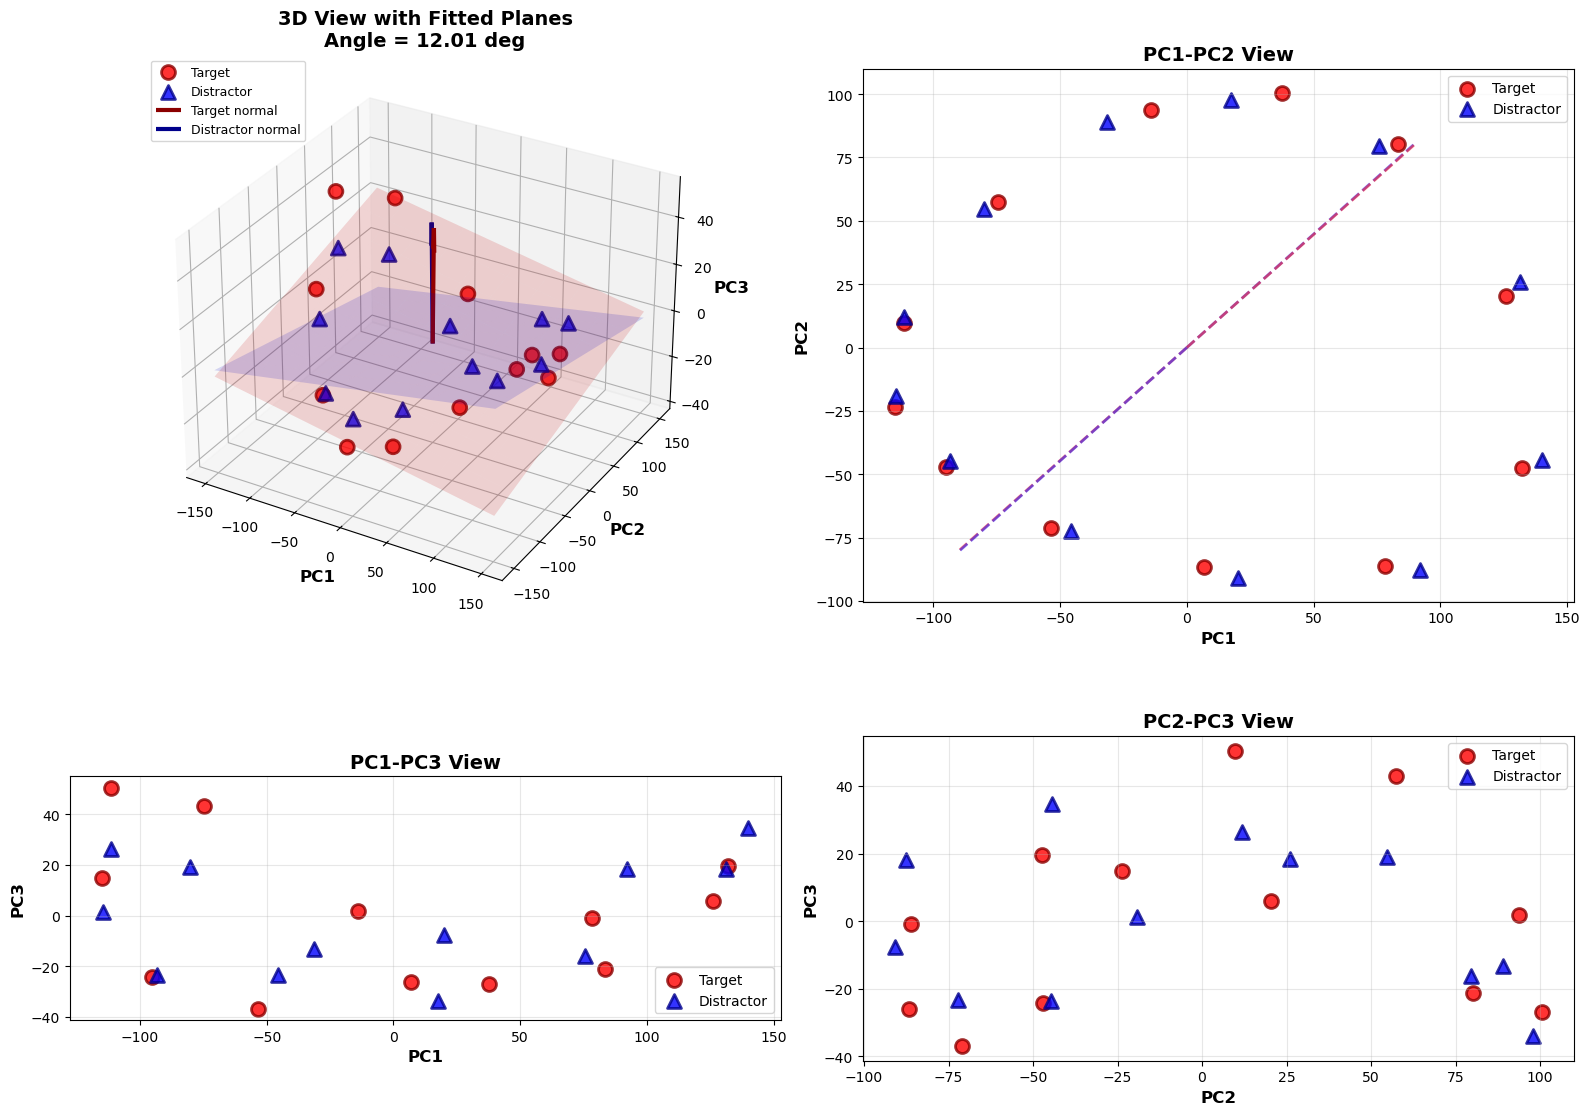

Saved: /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis/results/index_cued_first_diffusion_0.3_swap_recovery_6_sampled_trajectories/plane_fitting_visualization.png


In [17]:
# Visualize fitted target/distractor planes (2x2), matching original figure style
def create_plane_mesh(normal, center, size=150):
    if abs(normal[0]) < 0.9:
        v1 = np.array([1, 0, 0])
    else:
        v1 = np.array([0, 1, 0])
    v1 = v1 - np.dot(v1, normal) * normal
    v1 = v1 / np.linalg.norm(v1)
    v2 = np.cross(normal, v1)
    v2 = v2 / np.linalg.norm(v2)
    u = np.linspace(-size, size, 10)
    v = np.linspace(-size, size, 10)
    U, V = np.meshgrid(u, v)
    X = center[0] + U * v1[0] + V * v2[0]
    Y = center[1] + U * v1[1] + V * v2[1]
    Z = center[2] + U * v1[2] + V * v2[2]
    return X, Y, Z

target_X, target_Y, target_Z = create_plane_mesh(target_normal, target_center)
distractor_X, distractor_Y, distractor_Z = create_plane_mesh(distractor_normal, distractor_center)

fig = plt.figure(figsize=(16, 12))

ax = fig.add_subplot(2, 2, 1, projection='3d')
ax.plot_surface(target_X, target_Y, target_Z, alpha=0.15, color='red')
ax.plot_surface(distractor_X, distractor_Y, distractor_Z, alpha=0.15, color='blue')
ax.scatter(target_pca[:, 0], target_pca[:, 1], target_pca[:, 2], c='red', marker='o', s=100, edgecolors='darkred', linewidths=2, alpha=0.8, label='Target')
ax.scatter(distractor_pca[:, 0], distractor_pca[:, 1], distractor_pca[:, 2], c='blue', marker='^', s=100, edgecolors='darkblue', linewidths=2, alpha=0.8, label='Distractor')
arrow_scale = 50
ax.quiver(0, 0, 0, target_normal[0] * arrow_scale, target_normal[1] * arrow_scale, target_normal[2] * arrow_scale, color='darkred', arrow_length_ratio=0.2, linewidth=3, label='Target normal')
ax.quiver(0, 0, 0, distractor_normal[0] * arrow_scale, distractor_normal[1] * arrow_scale, distractor_normal[2] * arrow_scale, color='darkblue', arrow_length_ratio=0.2, linewidth=3, label='Distractor normal')
ax.set_xlabel('PC1', fontsize=12, fontweight='bold')
ax.set_ylabel('PC2', fontsize=12, fontweight='bold')
ax.set_zlabel('PC3', fontsize=12, fontweight='bold')
ax.set_title(f'3D View with Fitted Planes\nAngle = {plane_angle:.2f} deg', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)

ax2 = fig.add_subplot(2, 2, 2)
ax2.scatter(target_pca[:, 0], target_pca[:, 1], c='red', marker='o', s=100, edgecolors='darkred', linewidths=2, alpha=0.8, label='Target')
ax2.scatter(distractor_pca[:, 0], distractor_pca[:, 1], c='blue', marker='^', s=100, edgecolors='darkblue', linewidths=2, alpha=0.8, label='Distractor')
target_normal_proj = target_normal[:2] / np.linalg.norm(target_normal[:2])
distractor_normal_proj = distractor_normal[:2] / np.linalg.norm(distractor_normal[:2])
target_line_dir = np.array([-target_normal_proj[1], target_normal_proj[0]])
distractor_line_dir = np.array([-distractor_normal_proj[1], distractor_normal_proj[0]])
line_length = 120
for sign in [-1, 1]:
    ax2.plot([0, sign * line_length * target_line_dir[0]], [0, sign * line_length * target_line_dir[1]], 'r--', linewidth=2, alpha=0.5)
    ax2.plot([0, sign * line_length * distractor_line_dir[0]], [0, sign * line_length * distractor_line_dir[1]], 'b--', linewidth=2, alpha=0.5)
ax2.set_xlabel('PC1', fontsize=12, fontweight='bold')
ax2.set_ylabel('PC2', fontsize=12, fontweight='bold')
ax2.set_title('PC1-PC2 View', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal')

ax3 = fig.add_subplot(2, 2, 3)
ax3.scatter(target_pca[:, 0], target_pca[:, 2], c='red', marker='o', s=100, edgecolors='darkred', linewidths=2, alpha=0.8, label='Target')
ax3.scatter(distractor_pca[:, 0], distractor_pca[:, 2], c='blue', marker='^', s=100, edgecolors='darkblue', linewidths=2, alpha=0.8, label='Distractor')
ax3.set_xlabel('PC1', fontsize=12, fontweight='bold')
ax3.set_ylabel('PC3', fontsize=12, fontweight='bold')
ax3.set_title('PC1-PC3 View', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_aspect('equal')

ax4 = fig.add_subplot(2, 2, 4)
ax4.scatter(target_pca[:, 1], target_pca[:, 2], c='red', marker='o', s=100, edgecolors='darkred', linewidths=2, alpha=0.8, label='Target')
ax4.scatter(distractor_pca[:, 1], distractor_pca[:, 2], c='blue', marker='^', s=100, edgecolors='darkblue', linewidths=2, alpha=0.8, label='Distractor')
ax4.set_xlabel('PC2', fontsize=12, fontweight='bold')
ax4.set_ylabel('PC3', fontsize=12, fontweight='bold')
ax4.set_title('PC2-PC3 View', fontsize=14, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)
ax4.set_aspect('equal')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'plane_fitting_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved:', RESULTS_DIR / 'plane_fitting_visualization.png')

In [11]:
all_prep_results = {}

for prep_idx in PREP_INDICES:
    states = states_by_prep[prep_idx]
    averaged, _ = bin_and_average_by_cued_color(states, metadata, n_bins=N_BINS)
    stacked = np.vstack([averaged[1], averaged[2]])
    valid = ~np.isnan(stacked).any(axis=1)
    stacked = stacked[valid]

    pca_prep = PCA(n_components=3)
    coords = pca_prep.fit_transform(stacked)

    cue1_pca = coords[:N_BINS]
    cue2_pca = coords[N_BINS:N_BINS * 2]

    cue1_normal, cue1_center, cue1_planarity, _ = fit_plane_to_data(cue1_pca)
    cue2_normal, cue2_center, cue2_planarity, _ = fit_plane_to_data(cue2_pca)

    ang = angle_between_planes_degrees(cue1_normal, cue2_normal)
    sep = np.linalg.norm(cue1_center - cue2_center)

    all_prep_results[prep_idx] = {
        'plane_angle': float(ang),
        'separation': float(sep),
        'cue1_planarity': float(cue1_planarity),
        'cue2_planarity': float(cue2_planarity),
        'explained_variance': pca_prep.explained_variance_ratio_.tolist(),
    }

print('Prep-wise summary:')
for prep_idx in PREP_INDICES:
    r = all_prep_results[prep_idx]
    print(f'  prep_idx={prep_idx}: angle={r["plane_angle"]:.2f} deg, sep={r["separation"]:.4f}, C1plan={100*r["cue1_planarity"]:.1f}%, C2plan={100*r["cue2_planarity"]:.1f}%')

Prep-wise summary:
  prep_idx=0: angle=25.21 deg, sep=10.6855, C1plan=90.1%, C2plan=85.2%
  prep_idx=1: angle=48.91 deg, sep=26.3857, C1plan=89.3%, C2plan=83.6%
  prep_idx=2: angle=21.82 deg, sep=34.7672, C1plan=95.8%, C2plan=95.7%
  prep_idx=3: angle=23.12 deg, sep=43.5367, C1plan=95.4%, C2plan=96.4%


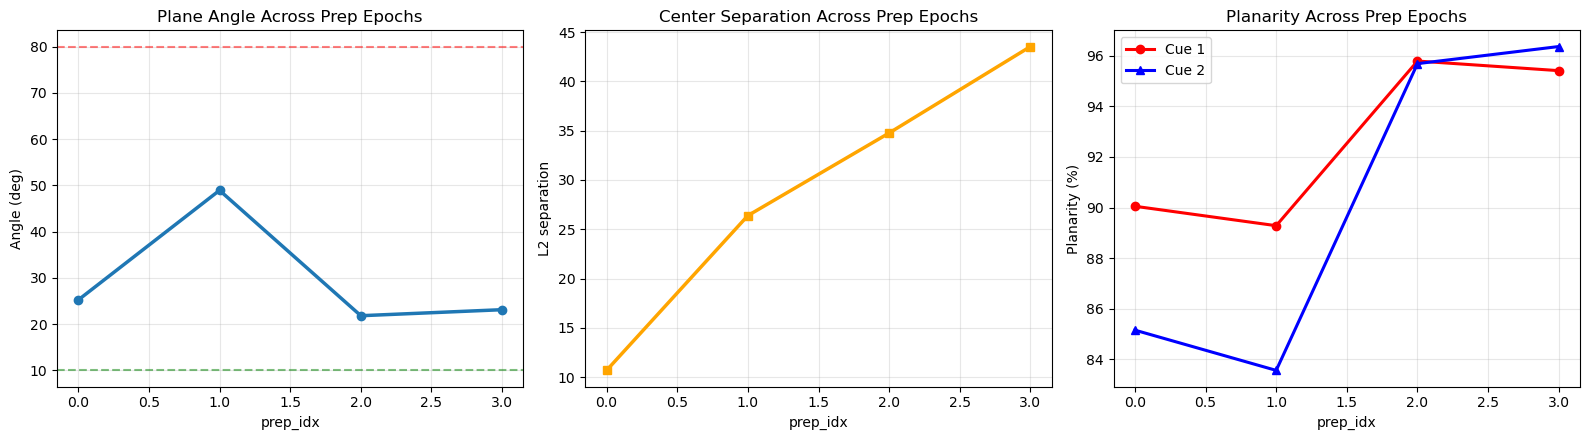

In [12]:
angles = [all_prep_results[i]['plane_angle'] for i in PREP_INDICES]
seps = [all_prep_results[i]['separation'] for i in PREP_INDICES]
p1 = [100 * all_prep_results[i]['cue1_planarity'] for i in PREP_INDICES]
p2 = [100 * all_prep_results[i]['cue2_planarity'] for i in PREP_INDICES]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(PREP_INDICES, angles, 'o-', linewidth=2.5)
axes[0].axhline(10, color='green', linestyle='--', alpha=0.5)
axes[0].axhline(80, color='red', linestyle='--', alpha=0.5)
axes[0].set_title('Plane Angle Across Prep Epochs')
axes[0].set_xlabel('prep_idx')
axes[0].set_ylabel('Angle (deg)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(PREP_INDICES, seps, 's-', linewidth=2.5, color='orange')
axes[1].set_title('Center Separation Across Prep Epochs')
axes[1].set_xlabel('prep_idx')
axes[1].set_ylabel('L2 separation')
axes[1].grid(True, alpha=0.3)

axes[2].plot(PREP_INDICES, p1, 'o-', linewidth=2.2, color='red', label='Cue 1')
axes[2].plot(PREP_INDICES, p2, '^-', linewidth=2.2, color='blue', label='Cue 2')
axes[2].set_title('Planarity Across Prep Epochs')
axes[2].set_xlabel('prep_idx')
axes[2].set_ylabel('Planarity (%)')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'plane_fitting_across_prep_epochs_sampled.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Build rich prep-epoch data (with PCA coordinates) for full visualization parity
prep_names = {
    0: 'Cue Presentation',
    1: 'Post-Cue / Delay 1 Start',
    2: 'Stimulus Presentation / Delay 1 End',
    3: 'Post-Stimulus / Delay 2',
}

all_prep_plot_data = {}

for prep_idx in PREP_INDICES:
    states = states_by_prep[prep_idx]
    averaged_states_prep, _ = bin_and_average_by_cued_color(states, metadata, n_bins=N_BINS)
    stacked = np.vstack([averaged_states_prep[1], averaged_states_prep[2]])
    labels = np.array([1] * N_BINS + [2] * N_BINS)
    valid = ~np.isnan(stacked).any(axis=1)
    stacked_clean = stacked[valid]
    labels_clean = labels[valid]

    pca_prep = PCA(n_components=3)
    pca_coords_prep = pca_prep.fit_transform(stacked_clean)

    cue1_pca_prep = pca_coords_prep[labels_clean == 1]
    cue2_pca_prep = pca_coords_prep[labels_clean == 2]

    cue1_normal, cue1_center, cue1_planarity, cue1_variance = fit_plane_to_data(cue1_pca_prep)
    cue2_normal, cue2_center, cue2_planarity, cue2_variance = fit_plane_to_data(cue2_pca_prep)

    plane_angle_prep = angle_between_planes_degrees(cue1_normal, cue2_normal)
    separation_prep = np.linalg.norm(cue1_center - cue2_center)

    all_prep_plot_data[prep_idx] = {
        'cue1_pca': cue1_pca_prep,
        'cue2_pca': cue2_pca_prep,
        'cue1_normal': cue1_normal,
        'cue2_normal': cue2_normal,
        'cue1_center': cue1_center,
        'cue2_center': cue2_center,
        'cue1_planarity': cue1_planarity,
        'cue2_planarity': cue2_planarity,
        'cue1_variance': cue1_variance,
        'cue2_variance': cue2_variance,
        'plane_angle': plane_angle_prep,
        'separation': separation_prep,
        'explained_variance': pca_prep.explained_variance_ratio_,
    }

print('Prepared detailed prep plotting data for all prep indices.')

Prepared detailed prep plotting data for all prep indices.


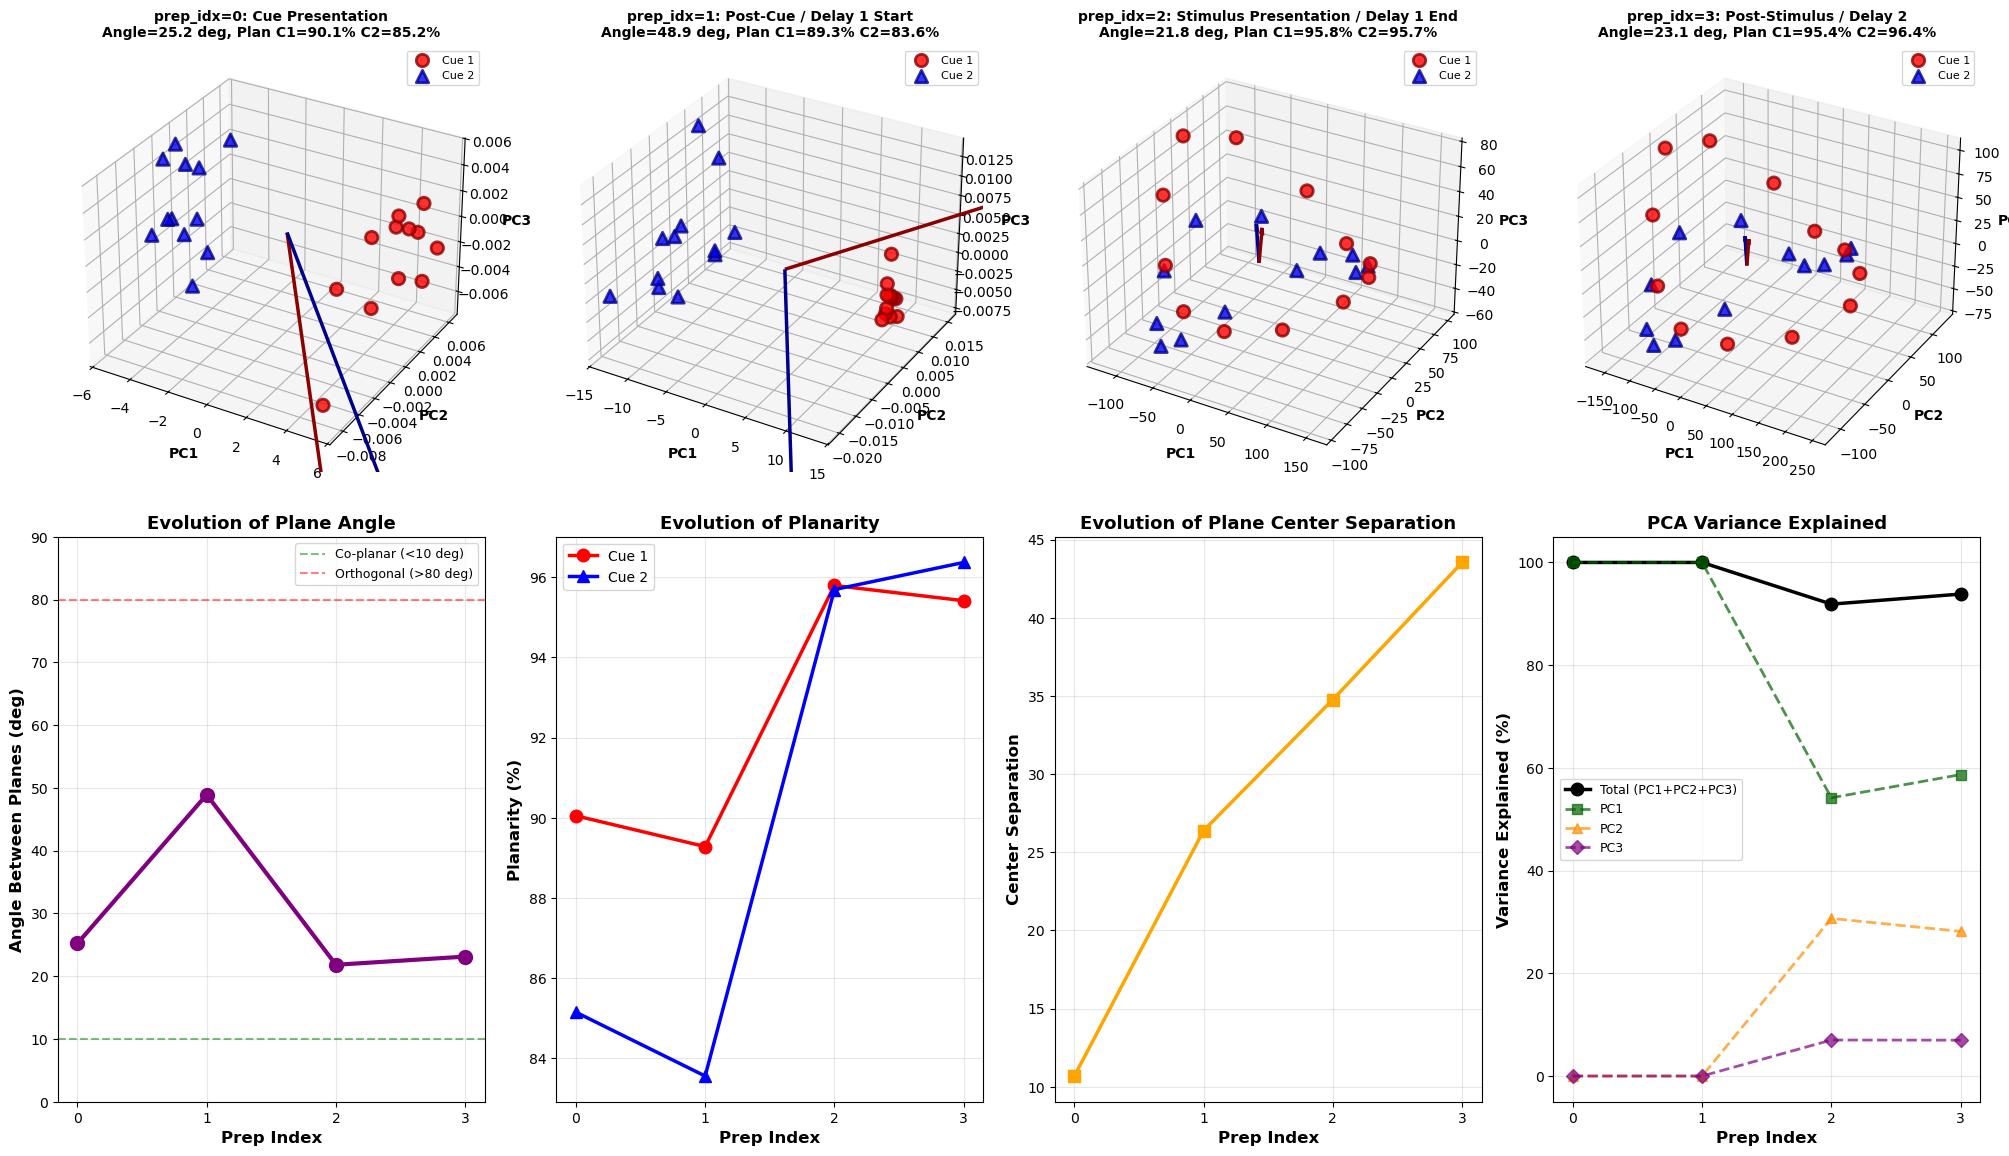

Saved: /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis/results/index_cued_first_diffusion_0.3_swap_recovery_6_sampled_trajectories/plane_fitting_across_prep_epochs.png


In [19]:
# Visualize plane fitting results across all prep epochs (2x4 grid)
fig = plt.figure(figsize=(20, 12))

for i, prep_idx in enumerate(PREP_INDICES):
    res = all_prep_plot_data[prep_idx]
    ax = fig.add_subplot(2, 4, i + 1, projection='3d')

    ax.scatter(res['cue1_pca'][:, 0], res['cue1_pca'][:, 1], res['cue1_pca'][:, 2], c='red', marker='o', s=80, edgecolors='darkred', linewidths=2, alpha=0.8, label='Cue 1')
    ax.scatter(res['cue2_pca'][:, 0], res['cue2_pca'][:, 1], res['cue2_pca'][:, 2], c='blue', marker='^', s=80, edgecolors='darkblue', linewidths=2, alpha=0.8, label='Cue 2')

    arrow_scale = 30
    ax.quiver(0, 0, 0, res['cue1_normal'][0] * arrow_scale, res['cue1_normal'][1] * arrow_scale, res['cue1_normal'][2] * arrow_scale, color='darkred', arrow_length_ratio=0.2, linewidth=2.5)
    ax.quiver(0, 0, 0, res['cue2_normal'][0] * arrow_scale, res['cue2_normal'][1] * arrow_scale, res['cue2_normal'][2] * arrow_scale, color='darkblue', arrow_length_ratio=0.2, linewidth=2.5)

    ax.set_xlabel('PC1', fontsize=10, fontweight='bold')
    ax.set_ylabel('PC2', fontsize=10, fontweight='bold')
    ax.set_zlabel('PC3', fontsize=10, fontweight='bold')
    ax.set_title(f'prep_idx={prep_idx}: {prep_names[prep_idx]}\nAngle={res["plane_angle"]:.1f} deg, Plan C1={res["cue1_planarity"]:.1%} C2={res["cue2_planarity"]:.1%}', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)

ax_summary = fig.add_subplot(2, 4, 5)
angles = [all_prep_plot_data[idx]['plane_angle'] for idx in PREP_INDICES]
ax_summary.plot(PREP_INDICES, angles, 'o-', linewidth=3, markersize=10, color='purple')
ax_summary.set_xlabel('Prep Index', fontsize=12, fontweight='bold')
ax_summary.set_ylabel('Angle Between Planes (deg)', fontsize=12, fontweight='bold')
ax_summary.set_title('Evolution of Plane Angle', fontsize=13, fontweight='bold')
ax_summary.grid(True, alpha=0.3)
ax_summary.set_xticks(PREP_INDICES)
ax_summary.set_ylim([0, 90])
ax_summary.axhline(y=10, color='green', linestyle='--', alpha=0.5, label='Co-planar (<10 deg)')
ax_summary.axhline(y=80, color='red', linestyle='--', alpha=0.5, label='Orthogonal (>80 deg)')
ax_summary.legend(fontsize=9)

ax_plan = fig.add_subplot(2, 4, 6)
cue1_plan = [all_prep_plot_data[idx]['cue1_planarity'] * 100 for idx in PREP_INDICES]
cue2_plan = [all_prep_plot_data[idx]['cue2_planarity'] * 100 for idx in PREP_INDICES]
ax_plan.plot(PREP_INDICES, cue1_plan, 'o-', linewidth=2.5, markersize=9, color='red', label='Cue 1')
ax_plan.plot(PREP_INDICES, cue2_plan, '^-', linewidth=2.5, markersize=9, color='blue', label='Cue 2')
ax_plan.set_xlabel('Prep Index', fontsize=12, fontweight='bold')
ax_plan.set_ylabel('Planarity (%)', fontsize=12, fontweight='bold')
ax_plan.set_title('Evolution of Planarity', fontsize=13, fontweight='bold')
ax_plan.grid(True, alpha=0.3)
ax_plan.set_xticks(PREP_INDICES)
ax_plan.legend(fontsize=10)

ax_sep = fig.add_subplot(2, 4, 7)
separations = [all_prep_plot_data[idx]['separation'] for idx in PREP_INDICES]
ax_sep.plot(PREP_INDICES, separations, 's-', linewidth=2.5, markersize=9, color='orange')
ax_sep.set_xlabel('Prep Index', fontsize=12, fontweight='bold')
ax_sep.set_ylabel('Center Separation', fontsize=12, fontweight='bold')
ax_sep.set_title('Evolution of Plane Center Separation', fontsize=13, fontweight='bold')
ax_sep.grid(True, alpha=0.3)
ax_sep.set_xticks(PREP_INDICES)

ax_var = fig.add_subplot(2, 4, 8)
var_totals = [all_prep_plot_data[idx]['explained_variance'].sum() * 100 for idx in PREP_INDICES]
var_pc1 = [all_prep_plot_data[idx]['explained_variance'][0] * 100 for idx in PREP_INDICES]
var_pc2 = [all_prep_plot_data[idx]['explained_variance'][1] * 100 for idx in PREP_INDICES]
var_pc3 = [all_prep_plot_data[idx]['explained_variance'][2] * 100 for idx in PREP_INDICES]
ax_var.plot(PREP_INDICES, var_totals, 'o-', linewidth=2.5, markersize=9, color='black', label='Total (PC1+PC2+PC3)')
ax_var.plot(PREP_INDICES, var_pc1, 's--', linewidth=2, markersize=7, color='darkgreen', alpha=0.7, label='PC1')
ax_var.plot(PREP_INDICES, var_pc2, '^--', linewidth=2, markersize=7, color='darkorange', alpha=0.7, label='PC2')
ax_var.plot(PREP_INDICES, var_pc3, 'D--', linewidth=2, markersize=7, color='purple', alpha=0.7, label='PC3')
ax_var.set_xlabel('Prep Index', fontsize=12, fontweight='bold')
ax_var.set_ylabel('Variance Explained (%)', fontsize=12, fontweight='bold')
ax_var.set_title('PCA Variance Explained', fontsize=13, fontweight='bold')
ax_var.grid(True, alpha=0.3)
ax_var.set_xticks(PREP_INDICES)
ax_var.legend(fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'plane_fitting_across_prep_epochs.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved:', RESULTS_DIR / 'plane_fitting_across_prep_epochs.png')

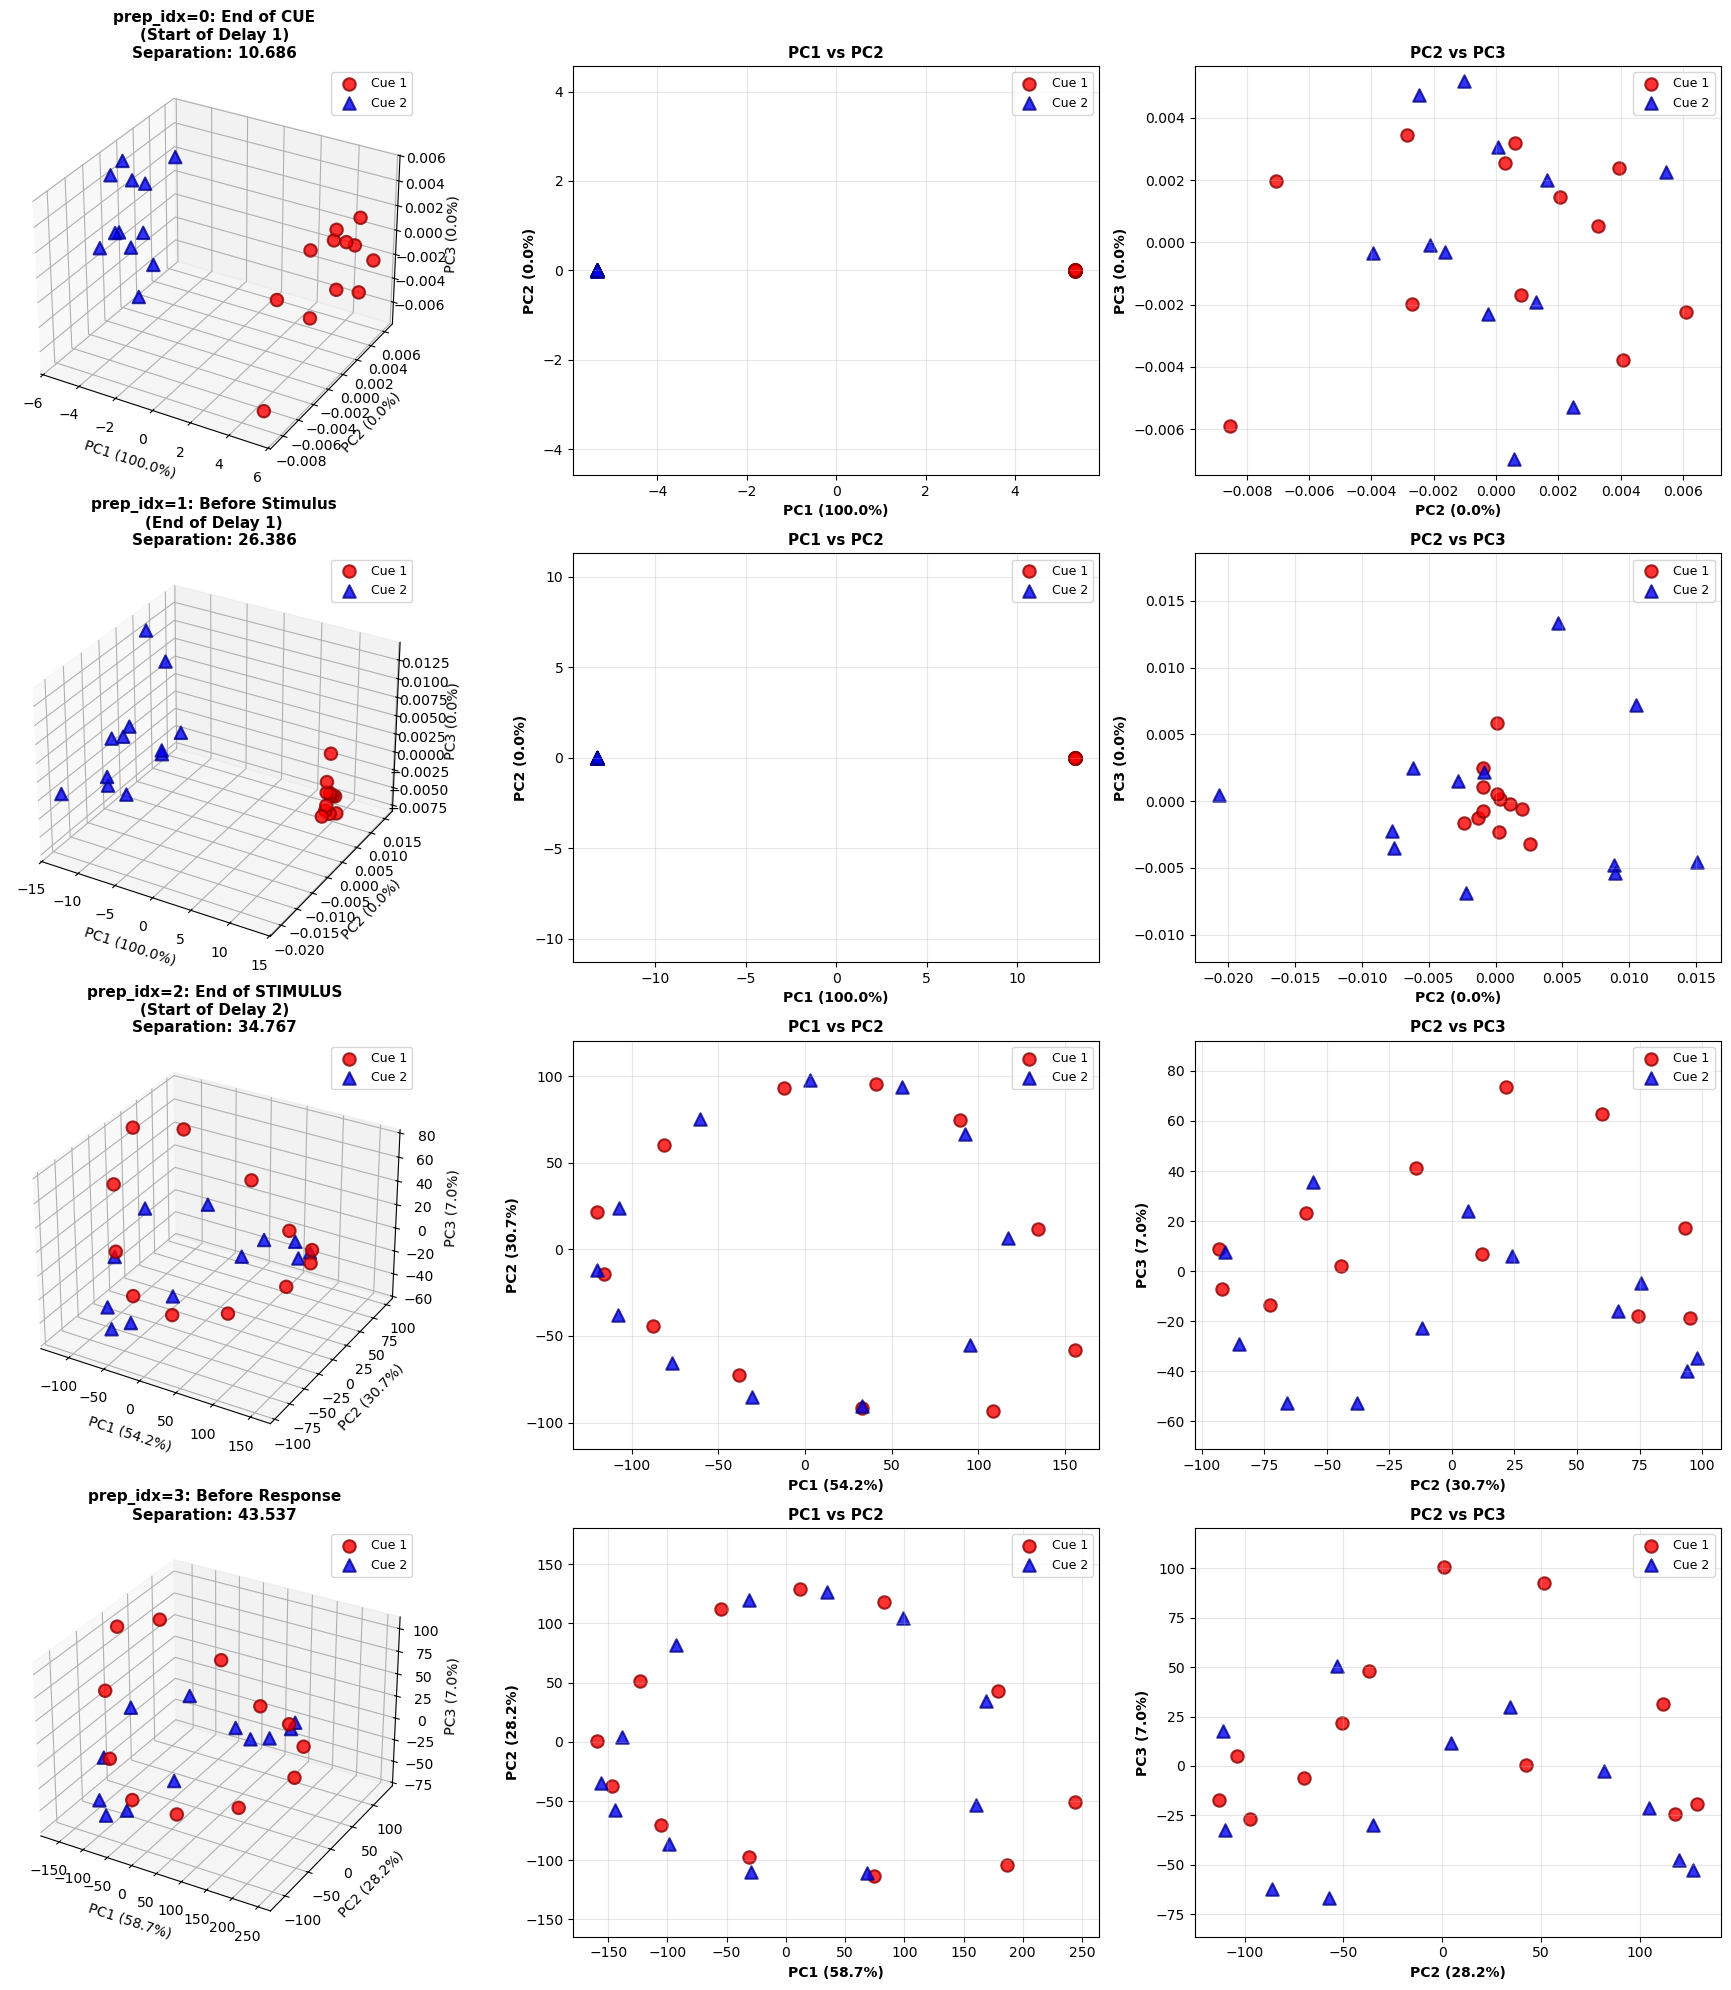

Saved: /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis/results/index_cued_first_diffusion_0.3_swap_recovery_6_sampled_trajectories/prospective_memory_all_prep_indices.png


In [20]:
# Create prospective memory visualization across all prep indices (4x3 grid)
fig = plt.figure(figsize=(18, 20))

prep_title_names = {
    0: 'prep_idx=0: End of CUE\n(Start of Delay 1)',
    1: 'prep_idx=1: Before Stimulus\n(End of Delay 1)',
    2: 'prep_idx=2: End of STIMULUS\n(Start of Delay 2)',
    3: 'prep_idx=3: Before Response',
}

for row_idx, prep_idx in enumerate(PREP_INDICES):
    res = all_prep_plot_data[prep_idx]
    sep = res['separation']
    var_ratio = res['explained_variance']

    ax_3d = fig.add_subplot(4, 3, row_idx * 3 + 1, projection='3d')
    ax_3d.scatter(res['cue1_pca'][:, 0], res['cue1_pca'][:, 1], res['cue1_pca'][:, 2], c='red', marker='o', s=80, edgecolors='darkred', linewidths=1.5, label='Cue 1', alpha=0.8)
    ax_3d.scatter(res['cue2_pca'][:, 0], res['cue2_pca'][:, 1], res['cue2_pca'][:, 2], c='blue', marker='^', s=80, edgecolors='darkblue', linewidths=1.5, label='Cue 2', alpha=0.8)
    ax_3d.set_xlabel(f'PC1 ({var_ratio[0]:.1%})', fontsize=10)
    ax_3d.set_ylabel(f'PC2 ({var_ratio[1]:.1%})', fontsize=10)
    ax_3d.set_zlabel(f'PC3 ({var_ratio[2]:.1%})', fontsize=10)
    ax_3d.set_title(f"{prep_title_names[prep_idx]}\nSeparation: {sep:.3f}", fontsize=11, fontweight='bold')
    ax_3d.legend(fontsize=9)
    ax_3d.grid(True, alpha=0.3)

    ax_12 = fig.add_subplot(4, 3, row_idx * 3 + 2)
    ax_12.scatter(res['cue1_pca'][:, 0], res['cue1_pca'][:, 1], c='red', marker='o', s=80, edgecolors='darkred', linewidths=1.5, label='Cue 1', alpha=0.8)
    ax_12.scatter(res['cue2_pca'][:, 0], res['cue2_pca'][:, 1], c='blue', marker='^', s=80, edgecolors='darkblue', linewidths=1.5, label='Cue 2', alpha=0.8)
    ax_12.set_xlabel(f'PC1 ({var_ratio[0]:.1%})', fontsize=10, fontweight='bold')
    ax_12.set_ylabel(f'PC2 ({var_ratio[1]:.1%})', fontsize=10, fontweight='bold')
    ax_12.set_title('PC1 vs PC2', fontsize=11, fontweight='bold')
    ax_12.legend(fontsize=9)
    ax_12.grid(True, alpha=0.3)
    ax_12.axis('equal')

    ax_23 = fig.add_subplot(4, 3, row_idx * 3 + 3)
    ax_23.scatter(res['cue1_pca'][:, 1], res['cue1_pca'][:, 2], c='red', marker='o', s=80, edgecolors='darkred', linewidths=1.5, label='Cue 1', alpha=0.8)
    ax_23.scatter(res['cue2_pca'][:, 1], res['cue2_pca'][:, 2], c='blue', marker='^', s=80, edgecolors='darkblue', linewidths=1.5, label='Cue 2', alpha=0.8)
    ax_23.set_xlabel(f'PC2 ({var_ratio[1]:.1%})', fontsize=10, fontweight='bold')
    ax_23.set_ylabel(f'PC3 ({var_ratio[2]:.1%})', fontsize=10, fontweight='bold')
    ax_23.set_title('PC2 vs PC3', fontsize=11, fontweight='bold')
    ax_23.legend(fontsize=9)
    ax_23.grid(True, alpha=0.3)
    ax_23.axis('equal')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'prospective_memory_all_prep_indices.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved:', RESULTS_DIR / 'prospective_memory_all_prep_indices.png')

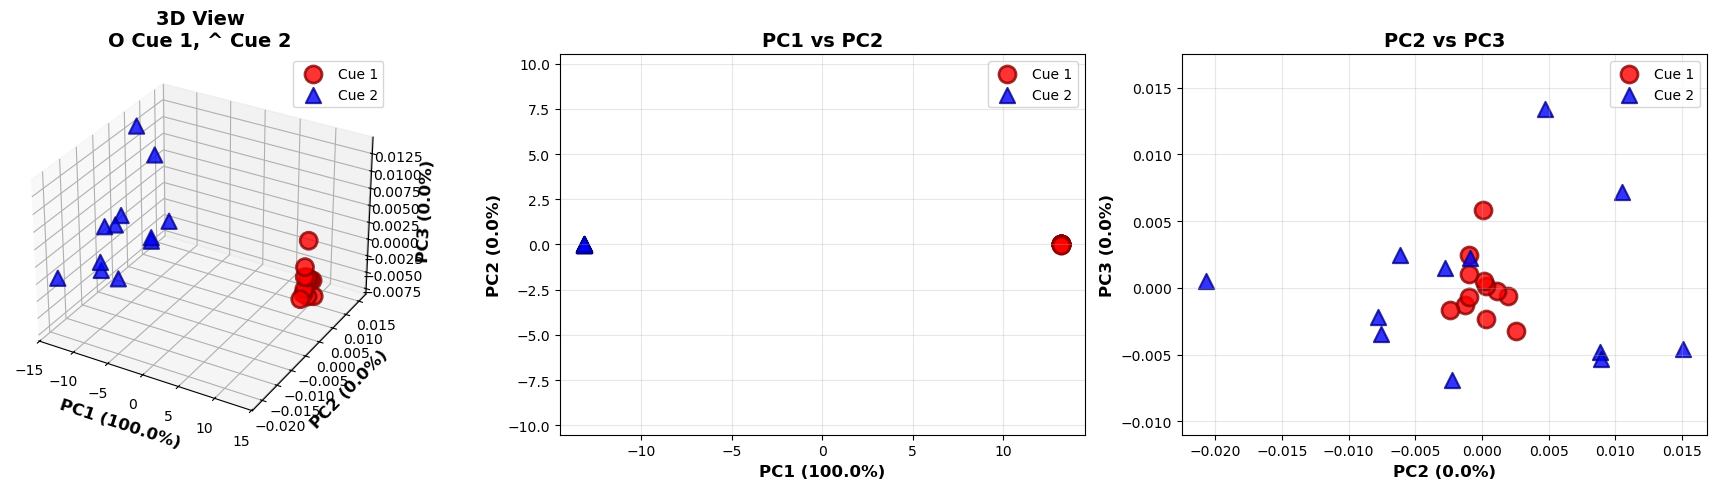

Saved: /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis/results/index_cued_first_diffusion_0.3_swap_recovery_6_sampled_trajectories/prep_idx_1_cue_colored.png


In [21]:
# Extract and visualize prep_idx=1 (post-cue / delay-1 onset) colored by cue
states_prep1 = states_by_prep[1]
metadata_prep1 = metadata.copy()

N_BINS_P1 = 12
binned_trials_p1 = {1: {}, 2: {}}
for state, meta in zip(states_prep1, metadata_prep1):
    cue = int(meta[0])
    target_angle = meta[1] if cue == 1 else meta[2]
    bin_idx = int(target_angle // 30)
    if bin_idx not in binned_trials_p1[cue]:
        binned_trials_p1[cue][bin_idx] = []
    binned_trials_p1[cue][bin_idx].append(state)

averaged_states_p1 = {1: {}, 2: {}}
for cue in [1, 2]:
    for bin_idx, states in binned_trials_p1[cue].items():
        averaged_states_p1[cue][bin_idx] = np.mean(states, axis=0)

all_binned_states_p1 = []
all_metadata_p1 = []
for cue in [1, 2]:
    for bin_idx, state in sorted(averaged_states_p1[cue].items()):
        all_binned_states_p1.append(state)
        all_metadata_p1.append([cue, bin_idx])

all_binned_states_p1 = np.array(all_binned_states_p1)
all_metadata_p1 = np.array(all_metadata_p1)

pca_p1 = PCA(n_components=3)
pca_coords_p1 = pca_p1.fit_transform(all_binned_states_p1)

cue1_pca_p1 = pca_coords_p1[all_metadata_p1[:, 0] == 1]
cue2_pca_p1 = pca_coords_p1[all_metadata_p1[:, 0] == 2]

fig = plt.figure(figsize=(18, 5))

ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(cue1_pca_p1[:, 0], cue1_pca_p1[:, 1], cue1_pca_p1[:, 2], c='red', marker='o', s=150, alpha=0.8, label='Cue 1', edgecolors='darkred', linewidth=2)
ax1.scatter(cue2_pca_p1[:, 0], cue2_pca_p1[:, 1], cue2_pca_p1[:, 2], c='blue', marker='^', s=120, alpha=0.8, label='Cue 2', edgecolors='darkblue', linewidth=1.5)
ax1.set_xlabel(f'PC1 ({pca_p1.explained_variance_ratio_[0]:.1%})', fontsize=12, fontweight='bold')
ax1.set_ylabel(f'PC2 ({pca_p1.explained_variance_ratio_[1]:.1%})', fontsize=12, fontweight='bold')
ax1.set_zlabel(f'PC3 ({pca_p1.explained_variance_ratio_[2]:.1%})', fontsize=12, fontweight='bold')
ax1.set_title('3D View\nO Cue 1, ^ Cue 2', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(132)
ax2.scatter(cue1_pca_p1[:, 0], cue1_pca_p1[:, 1], c='red', marker='o', s=150, alpha=0.8, label='Cue 1', edgecolors='darkred', linewidth=2)
ax2.scatter(cue2_pca_p1[:, 0], cue2_pca_p1[:, 1], c='blue', marker='^', s=120, alpha=0.8, label='Cue 2', edgecolors='darkblue', linewidth=1.5)
ax2.set_xlabel(f'PC1 ({pca_p1.explained_variance_ratio_[0]:.1%})', fontsize=12, fontweight='bold')
ax2.set_ylabel(f'PC2 ({pca_p1.explained_variance_ratio_[1]:.1%})', fontsize=12, fontweight='bold')
ax2.set_title('PC1 vs PC2', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.axis('equal')

ax3 = fig.add_subplot(133)
ax3.scatter(cue1_pca_p1[:, 1], cue1_pca_p1[:, 2], c='red', marker='o', s=150, alpha=0.8, label='Cue 1', edgecolors='darkred', linewidth=2)
ax3.scatter(cue2_pca_p1[:, 1], cue2_pca_p1[:, 2], c='blue', marker='^', s=120, alpha=0.8, label='Cue 2', edgecolors='darkblue', linewidth=1.5)
ax3.set_xlabel(f'PC2 ({pca_p1.explained_variance_ratio_[1]:.1%})', fontsize=12, fontweight='bold')
ax3.set_ylabel(f'PC3 ({pca_p1.explained_variance_ratio_[2]:.1%})', fontsize=12, fontweight='bold')
ax3.set_title('PC2 vs PC3', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.axis('equal')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'prep_idx_1_cue_colored.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved:', RESULTS_DIR / 'prep_idx_1_cue_colored.png')

In [22]:
np.savez(
    RESULTS_DIR / 'sampled_neural_states_primary.npz',
    neural_states=neural_states,
    metadata=metadata,
    prep_idx=PREP_IDX,
    n_bins=N_BINS,
)

summary = {
    'run_name': RUN_NAME,
    'trajectory_dir': str(TRAJ_DIR),
    'num_sweep_files': len(sweep_files),
    'num_trials': int(metadata.shape[0]),
    'state_dim': int(neural_states.shape[1]),
    'prep_idx_primary': PREP_IDX,
    'cue_separation_primary': float(separation),
    'pca_explained_variance_primary': pca.explained_variance_ratio_.tolist(),
    'target_distractor_plane_angle': float(plane_angle),
    'target_distractor_center_separation': float(plane_sep),
    'prep_epoch_results': all_prep_results,
}

with open(RESULTS_DIR / 'summary_sampled_trajectories.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('Saved outputs:')
print(' ', RESULTS_DIR / 'sampled_neural_states_primary.npz')
print(' ', RESULTS_DIR / 'summary_sampled_trajectories.json')
print(' ', RESULTS_DIR / 'prospective_memory_pca_3d_sampled.png')
print(' ', RESULTS_DIR / '2d_binning_target_vs_distractor_combined.png')
print(' ', RESULTS_DIR / 'plane_fitting_visualization.png')
print(' ', RESULTS_DIR / 'plane_fitting_across_prep_epochs.png')
print(' ', RESULTS_DIR / 'prospective_memory_all_prep_indices.png')
print(' ', RESULTS_DIR / 'prep_idx_1_cue_colored.png')

Saved outputs:
  /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis/results/index_cued_first_diffusion_0.3_swap_recovery_6_sampled_trajectories/sampled_neural_states_primary.npz
  /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis/results/index_cued_first_diffusion_0.3_swap_recovery_6_sampled_trajectories/summary_sampled_trajectories.json
  /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis/results/index_cued_first_diffusion_0.3_swap_recovery_6_sampled_trajectories/prospective_memory_pca_3d_sampled.png
  /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis/results/index_cued_first_diffusion_0.3_swap_recovery_6_sampled_trajectories/2d_binning_target_vs_distractor_combined.png
  /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis/results/index_cued_first_diffusion_0.3_swap_recovery_6_sampled_trajectories/plane_fitting_visualization.png
  /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analy